
Model Accuracy Report (optional backup):

              precision    recall  f1-score   support

           L       1.00      1.00      1.00        50
           M       1.00      1.00      1.00        86
           S       1.00      1.00      1.00        45
          XL       1.00      1.00      1.00        19

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Gender (Male/Female): Male
Height (in cm): 180
Weight (in kg): 67
Chest (in cm): 68
Waist (in cm): 78
Hip (in cm): 99

🔍 Please confirm your entered details:
1. Gender: Male
2. Height: 180.0 cm
3. Weight: 67.0 kg
4. Chest: 68.0 cm
5. Waist: 78.0 cm
6. Hip: 99.0 cm

✏️ Enter the number to correct (or type '0' if all correct): 0
👕 Select a brand (Zara, Nike, Levi's): Zara

🛍️ Brand: Zara
📏 Recommended clothing size: **M**



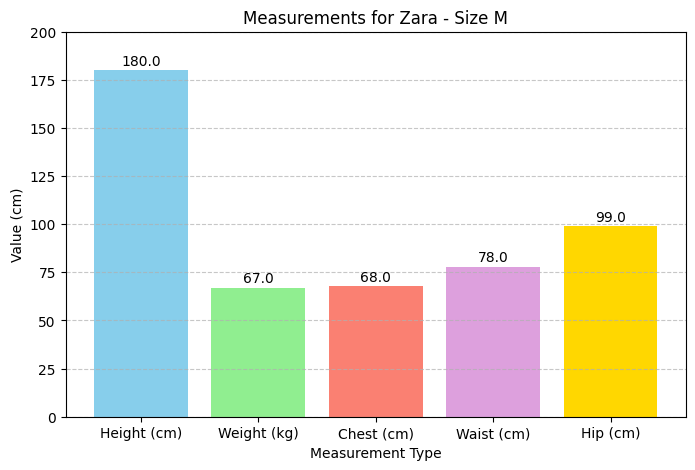

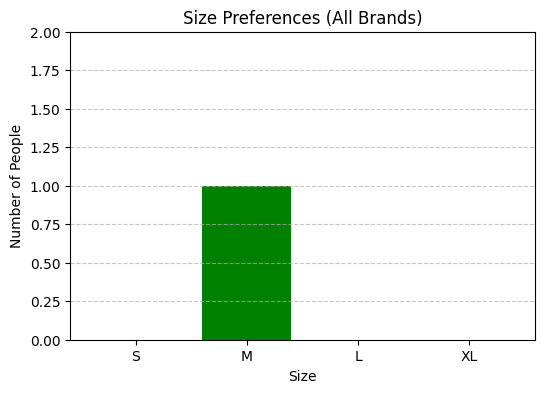

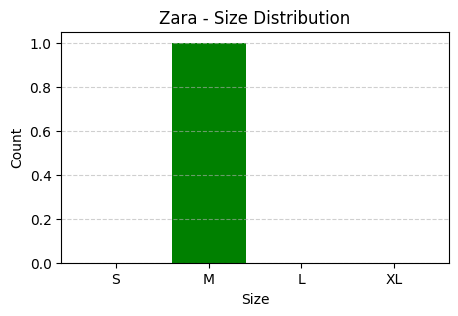


📊 Average measurements for Zara:
      height  weight  chest  waist   hip
size                                    
M      180.0    67.0   68.0   78.0  99.0


In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# Simulate training data for model (optional backup model logic)
np.random.seed(42)
n = 1000
height = np.random.normal(170, 10, n)
weight = np.random.normal(70, 15, n)
chest = weight * 0.9 + np.random.normal(0, 5, n)
waist = weight * 0.8 + np.random.normal(0, 5, n)
hip = weight * 0.95 + np.random.normal(0, 5, n)
gender = np.random.choice(['Male', 'Female'], size=n)

size = pd.cut(weight, bins=[0, 60, 75, 90, 200], labels=['S', 'M', 'L', 'XL'])

df = pd.DataFrame({
    'gender': gender,
    'height_cm': height,
    'weight_kg': weight,
    'chest_cm': chest,
    'waist_cm': waist,
    'hip_cm': hip,
    'size': size
})

le_gender = LabelEncoder()
df['gender'] = le_gender.fit_transform(df['gender'])

X = df.drop('size', axis=1)
y = df['size']

le_size = LabelEncoder()
y_encoded = le_size.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Print model accuracy (optional)
print("\nModel Accuracy Report (optional backup):\n")
print(classification_report(y_test, model.predict(X_test), target_names=le_size.classes_))

# Size counter dictionary
size_counter = {'S': 0, 'M': 0, 'L': 0, 'XL': 0}

# New: brand-specific tracking
brand_size_counter = {
    'Zara': {'S': 0, 'M': 0, 'L': 0, 'XL': 0},
    'Nike': {'S': 0, 'M': 0, 'L': 0, 'XL': 0},
    "Levi's": {'S': 0, 'M': 0, 'L': 0, 'XL': 0}
}

brand_measurements = {
    'Zara': [],
    'Nike': [],
    "Levi's": []
}

# Brand-based size logic
def get_size_by_brand(brand, weight, chest, waist):
    brand = brand.lower()
    if brand == 'zara':
        if weight <= 60:
            return 'S'
        elif weight <= 75:
            return 'M'
        elif weight <= 90:
            return 'L'
        else:
            return 'XL'
    elif brand == 'nike':
        if waist <= 75:
            return 'S'
        elif waist <= 85:
            return 'M'
        elif waist <= 95:
            return 'L'
        else:
            return 'XL'
    elif brand == "levi's" or brand == "levis":
        if chest <= 90:
            return 'S'
        elif chest <= 100:
            return 'M'
        elif chest <= 110:
            return 'L'
        else:
            return 'XL'
    else:
        return 'M'  # Default fallback

# Smart user input with correction
def get_user_input():
    while True:
        try:
            gender_input = input("Gender (Male/Female): ").strip()
            while gender_input not in ['Male', 'Female']:
                print("⚠️ Please enter 'Male' or 'Female' only.")
                gender_input = input("Gender (Male/Female): ").strip()

            height_in = float(input("Height (in cm): "))
            weight_in = float(input("Weight (in kg): "))
            chest_in = float(input("Chest (in cm): "))
            waist_in = float(input("Waist (in cm): "))
            hip_in = float(input("Hip (in cm): "))

            while True:
                print("\n🔍 Please confirm your entered details:")
                print(f"1. Gender: {gender_input}")
                print(f"2. Height: {height_in} cm")
                print(f"3. Weight: {weight_in} kg")
                print(f"4. Chest: {chest_in} cm")
                print(f"5. Waist: {waist_in} cm")
                print(f"6. Hip: {hip_in} cm")

                correction = input("\n✏️ Enter the number to correct (or type '0' if all correct): ").strip()

                if correction == '0':
                    return gender_input, height_in, weight_in, chest_in, waist_in, hip_in
                elif correction == '1':
                    gender_input = input("Gender (Male/Female): ").strip()
                elif correction == '2':
                    height_in = float(input("Height (in cm): "))
                elif correction == '3':
                    weight_in = float(input("Weight (in kg): "))
                elif correction == '4':
                    chest_in = float(input("Chest (in cm): "))
                elif correction == '5':
                    waist_in = float(input("Waist (in cm): "))
                elif correction == '6':
                    hip_in = float(input("Hip (in cm): "))
                else:
                    print("⚠️ Invalid choice. Enter a number between 0 and 6.")
        except ValueError:
            print("⚠️ Invalid input. Please enter numbers only.")

# ---------------- Main Loop ----------------

while True:
    gender_input, height_in, weight_in, chest_in, waist_in, hip_in = get_user_input()
    brand_input = input("👕 Select a brand (Zara, Nike, Levi's): ").strip()

    predicted_size = get_size_by_brand(brand_input, weight_in, chest_in, waist_in)

    if predicted_size in size_counter:
        size_counter[predicted_size] += 1

    brand_key = brand_input.capitalize()
    if predicted_size in brand_size_counter.get(brand_key, {}):
        brand_size_counter[brand_key][predicted_size] += 1

    if brand_key in brand_measurements:
        brand_measurements[brand_key].append({
            'height': height_in,
            'weight': weight_in,
            'chest': chest_in,
            'waist': waist_in,
            'hip': hip_in,
            'size': predicted_size
        })

    print(f"\n🛍️ Brand: {brand_input.capitalize()}")
    print(f"📏 Recommended clothing size: **{predicted_size}**\n")

    # Graph 1: Body Measurements
    features = ['Height (cm)', 'Weight (kg)', 'Chest (cm)', 'Waist (cm)', 'Hip (cm)']
    values = [height_in, weight_in, chest_in, waist_in, hip_in]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(features, values, color=['skyblue', 'lightgreen', 'salmon', 'plum', 'gold'])

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, round(yval, 1), ha='center', va='bottom')

    plt.title(f'Measurements for {brand_input.capitalize()} - Size {predicted_size}')
    plt.xlabel('Measurement Type')
    plt.ylabel('Value (cm)')
    plt.ylim(0, max(values) + 20)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Graph 2: Size Preferences
    plt.figure(figsize=(6, 4))
    sizes = list(size_counter.keys())
    counts = list(size_counter.values())

    plt.bar(sizes, counts, color=['blue', 'green', 'orange', 'red'])
    plt.title('Size Preferences (All Brands)')
    plt.xlabel('Size')
    plt.ylabel('Number of People')
    plt.ylim(0, max(counts) + 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Graph 3: Brand-specific size popularity
    for brand, size_data in brand_size_counter.items():
        sizes = list(size_data.keys())
        counts = list(size_data.values())
        if sum(counts) == 0:
            continue

        plt.figure(figsize=(5, 3))
        plt.bar(sizes, counts, color=['blue', 'green', 'orange', 'red'])
        plt.title(f'{brand} - Size Distribution')
        plt.xlabel('Size')
        plt.ylabel('Count')
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.show()

    # Print average measurements for each brand
    for brand, records in brand_measurements.items():
        if not records:
            continue
        df_brand = pd.DataFrame(records)
        avg_measures = df_brand.groupby('size').mean()

        print(f"\n📊 Average measurements for {brand}:")
        print(avg_measures.round(2))

    # Continue or Exit
    another = input("🔄 Do you want to predict for another user? (yes/no): ").strip().lower()
    if another != 'yes':
        print("\n👋 Thank you for using BrandFit Sizing Tool! Stay stylish.\n")
        break
